<a href="https://colab.research.google.com/github/sinnu2004/MLProjects/blob/main/DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("/content/student_dataset_10000_rows.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [5]:
df.isnull().sum()

,0
study_hours,0
attendance,0
sleep_hours,0
internet_usage,0
assignments_completed,0
previous_score,0
exam_score,0
placement_status,0


In [6]:
encode = LabelEncoder()

In [7]:
encoded_data = encode.fit_transform(df['placement_status'])

In [8]:
encoded_data

array([1, 1, 1, ..., 1, 1, 1])

In [9]:
encoded_data = pd.DataFrame(encoded_data,columns=['placement_status'])

In [10]:
encoded_data

,placement_status
0,1
1,1
2,1
3,1
4,1
...,...
9995,0
9996,1
9997,1
9998,1


In [11]:
df

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
...,...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31,Not Placed
9996,7,98,6,9,4,87,100.00,Placed
9997,10,44,8,5,10,37,95.94,Placed
9998,10,75,7,5,8,52,88.61,Placed


In [12]:
df['placement_status'] = encoded_data

In [13]:
df

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,1
1,4,69,5,3,8,56,100.00,1
2,11,60,7,6,10,45,100.00,1
3,8,99,9,8,4,55,90.17,1
4,5,52,8,6,8,40,78.82,1
...,...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31,0
9996,7,98,6,9,4,87,100.00,1
9997,10,44,8,5,10,37,95.94,1
9998,10,75,7,5,8,52,88.61,1


In [14]:
x = df.drop(columns=['placement_status'])

In [15]:
x

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
0,7,56,8,7,10,62,100.00
1,4,69,5,3,8,56,100.00
2,11,60,7,6,10,45,100.00
3,8,99,9,8,4,55,90.17
4,5,52,8,6,8,40,78.82
...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31
9996,7,98,6,9,4,87,100.00
9997,10,44,8,5,10,37,95.94
9998,10,75,7,5,8,52,88.61


In [16]:
y = df['placement_status']

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
model = DecisionTreeRegressor()

In [19]:
model.fit(x_train,y_train)

DecisionTreeRegressor()

In [27]:
y_pred = model.predict(x_test)

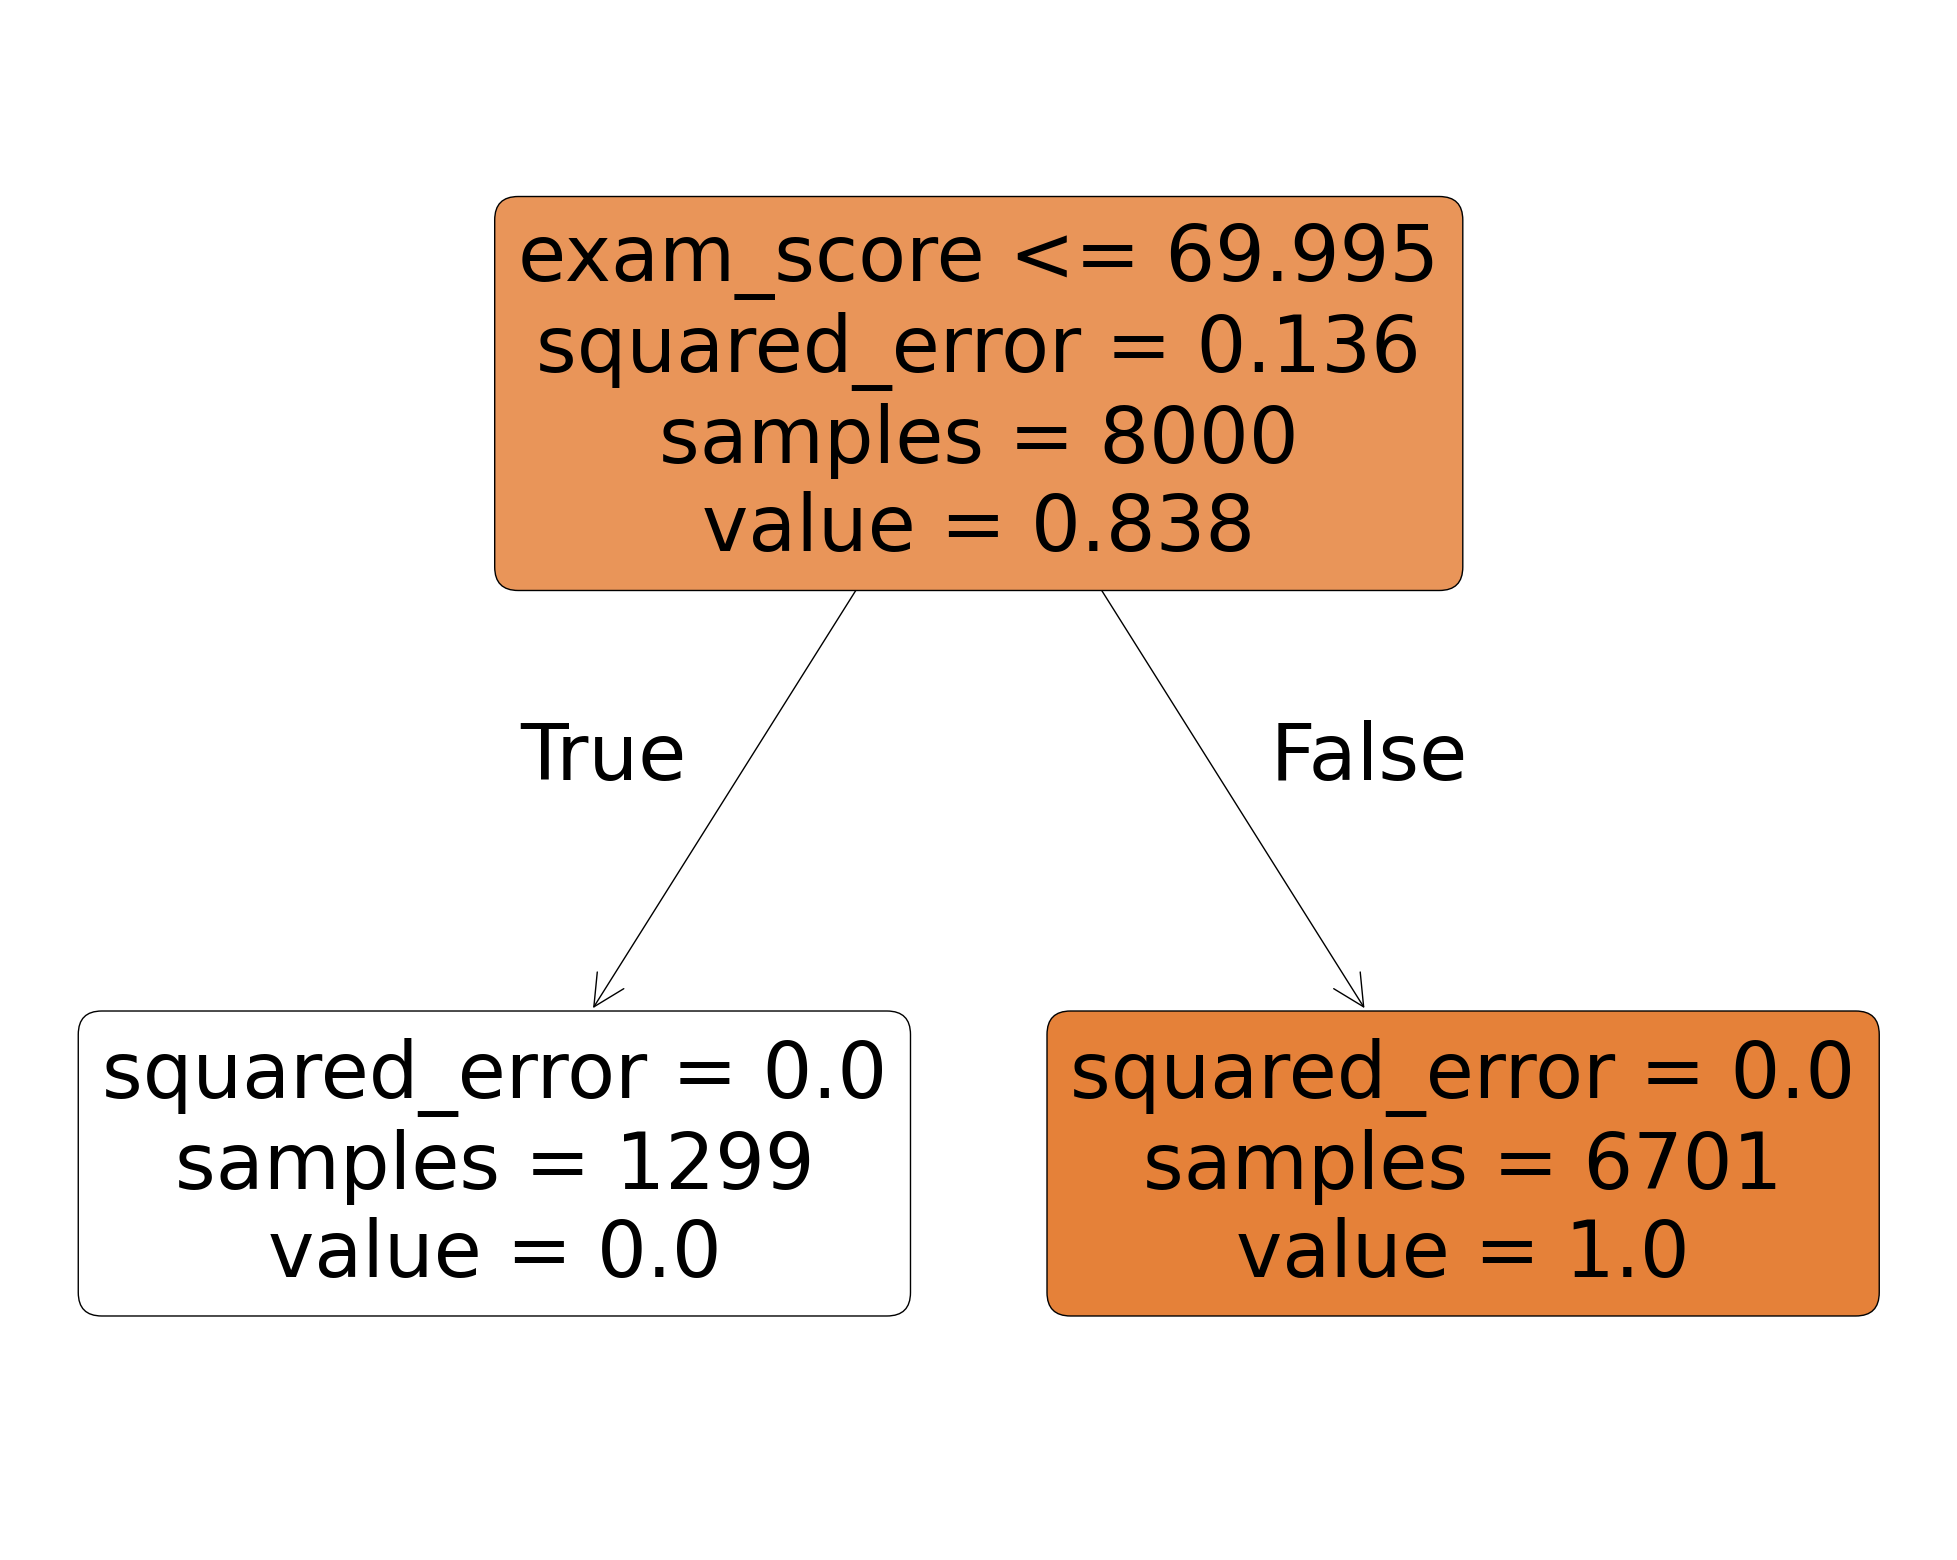

In [20]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(25,20))
plot_tree(
    model,
    feature_names=x.columns,
    filled=True,
    rounded=True
)
plt.show()

In [21]:
new_student = [[
    12,
    70,
    9,
    7,
    8,
    20,
    20
]]

In [22]:
prediction = model.predict(new_student)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [23]:
prediction

array([0.])

In [24]:
training = model.score(x_train,y_train)
testing = model.score(x_test,y_test)

In [25]:
print("Training Accuracy:",training*100)
print("Testing Accuracy:",testing*100)

Training Accuracy: 100.0
Testing Accuracy: 100.0


In [29]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))
print("R2 Score", r2_score(y_test,y_pred)*100)

MAE 0.0
MSE 0.0
R2 Score 100.0
